# 09 - Train the GPT

Everything is in place. Now we train the model from notebook 08 on Shakespeare and watch it learn. The loop is the same four lines as always (notebook 08's bigram used them too); the only difference is that the model in the middle is now a real Transformer.

What to watch for: the loss falling from about 4.2 (random) towards about 1.6, and the generated text turning from noise into something resembling a play, with character names, line breaks, dialogue, and mostly real words, all from one model and a few minutes on a GPU.

In [1]:
# Colab setup -- fetch the files this notebook needs.
# (Does nothing when run locally in the course folder.)
import os, urllib.request
BASE = ("https://raw.githubusercontent.com/waze"
        "emlabs/llm-book-code/main/")
for f in ['gpt.py', 'data/input.txt']:
    if not os.path.exists(f):
        d = os.path.dirname(f)
        if d: os.makedirs(d, exist_ok=True)
        urllib.request.urlretrieve(BASE + f, f)
        print("downloaded", f)


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>import os, urllib.request</code>: two standard-library toolboxes: checking files on disk, and downloading from the web.</li>
<li><code>BASE = (...)</code>: the web address of this course's folder on GitHub, split over two lines (Python glues adjacent strings together).</li>
<li><code>for f in [...]</code>: loop over the file names this notebook needs.</li>
<li><code>if not os.path.exists(f)</code>: only download what is missing -- running locally, everything already exists, so nothing happens.</li>
<li><code>os.makedirs(d, exist_ok=True)</code>: create the folder for the file if it has one (<code>exist_ok</code> means don't complain if it's already there).</li>
<li><code>urllib.request.urlretrieve(...)</code>: download the file and save it under the same name here.</li>
</ul>
</details>

In [2]:
import torch, time, math
from pathlib import Path
from gpt import GPT, GPTConfig
torch.manual_seed(1337)
device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print("training on:", device)

training on: mps


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>import torch, time, math</code>: PyTorch, plus <code>time</code> for the stopwatch and <code>math</code> for ln(65).</li>
<li><code>from gpt import GPT, GPTConfig</code>: the model classes you toured in notebook 08.</li>
<li><code>torch.manual_seed(1337)</code>: pin the randomness so training is reproducible.</li>
<li>The device line picks Apple GPU &rarr; NVIDIA &rarr; CPU, as before.</li>
</ul>
</details>

## Data and batching

Encode the text (notebook 02), hold out the last 10% as a **validation set**, and draw random `block_size` chunks for each step.

Why hold out that 10%? It is the model's practice exam: text that it never trains on. We watch two losses, the **train** loss (on text it studies) and the **validation** loss (on the held-out text). If both fall together, the model is genuinely learning the language. If the train loss keeps dropping while the validation loss stalls or creeps up, the model is **memorizing** the training text instead of learning patterns that carry over. That failure is called **overfitting**, and the gap between the two numbers is how you spot it.

In [3]:
text = Path("data/input.txt").read_text()
chars = sorted(set(text)); vocab_size = len(chars)
stoi = {c:i for i,c in enumerate(chars)}; itos = {i:c for c,i in stoi.items()}
encode = lambda s: [stoi[c] for c in s]; decode = lambda l: "".join(itos[i] for i in l)

data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9*len(data)); train_data, val_data = data[:n], data[n:]

block_size = 128     # context length
batch_size = 32      # sequences per step
def get_batch(split):
    d = train_data if split == "train" else val_data
    ix = torch.randint(len(d) - block_size, (batch_size,))
    x = torch.stack([d[i:i+block_size] for i in ix])
    y = torch.stack([d[i+1:i+1+block_size] for i in ix])
    return x.to(device), y.to(device)
print("train tokens:", len(train_data), "| val tokens:", len(val_data))

train tokens: 1003854 | val tokens: 111540


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li>The tokenizer and split are identical to notebook 02 (read the file, build the tables, encode, hold out the last 10%), in PyTorch tensors.</li>
<li><code>block_size = 128</code>: the context window is now 128 characters (the bigram saw 1).</li>
<li><code>batch_size = 32</code>: 32 sequences per training step.</li>
<li><code>def get_batch(split):</code>: same recipe as before: 32 random 128-long chunks as context <code>x</code>, the same chunks shifted one right as targets <code>y</code>, both shipped to the GPU.</li>
</ul>
</details>

## Model, optimizer, and an honest loss estimate

We build the same model of about 0.8 million numbers, now with a little **dropout** (set to 0.1). Dropout randomly switches off 10% of the signals on each training step, which stops the model from leaning too heavily on any single path. It is a bit like studying with random pages of your notes covered, so that you learn the material itself rather than memorizing one route to the answer. It is a standard guard against the overfitting just described, and it is active only during training.

`estimate_loss` averages the loss over many batches (150 of them here) before printing. A single batch is a noisy reading, because some stretches of text are simply easier than others, so averaging gives an honest number that can be compared fairly from one step to the next.

In [4]:
cfg = GPTConfig(vocab_size=vocab_size, block_size=block_size,
                n_layer=4, n_head=4, n_embd=128, dropout=0.1)
model = GPT(cfg).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
print(f"parameters: {model.num_params():,}")

eval_iters = 150
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ["train", "val"]:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            x, y = get_batch(split)
            _, loss = model(x, y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

parameters: 824,897


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>cfg = GPTConfig(..., dropout=0.1)</code>: the same model as notebook 08, now with 10% dropout switched on for training.</li>
<li><code>model = GPT(cfg).to(device)</code> / <code>optimizer = torch.optim.AdamW(..., lr=1e-3)</code>: build it on the GPU and hand its knobs to AdamW.</li>
<li><code>@torch.no_grad()</code>: decorator: everything inside runs without recording gradients (it's measurement, not learning).</li>
<li><code>model.eval()</code> / <code>model.train()</code>: flip the model's mode: <code>eval</code> turns dropout <i>off</i> for an honest measurement, <code>train</code> turns it back on. Forgetting this pair is a classic bug.</li>
<li><code>losses = torch.zeros(eval_iters)</code>: a 150-slot tensor; <code>losses[k] = loss.item()</code> fills slot k with a plain number.</li>
<li><code>out[split] = losses.mean().item()</code>: store each split's average loss in a dictionary: <code>{"train": ..., "val": ...}</code>.</li>
</ul>
</details>

## The training loop

The same five moves as always: sample a batch, forward, `zero_grad`, `backward`, `step`. Every `eval_interval` steps we pause to estimate the train and validation losses and print them. Reading the output below, both numbers drop quickly at first and then slow down, and the validation loss sits a little above the train loss (which is normal: the practice exam is always a touch harder than the homework). It runs in a couple of minutes on an Apple GPU; raise `max_iters` (and the model size in `cfg`) for sharper text.

In [5]:
max_iters = 3000
eval_interval = 500
history = []

t0 = time.time()
for it in range(max_iters + 1):
    if it % eval_interval == 0:
        l = estimate_loss()
        history.append((it, l["train"], l["val"]))
        print(f"step {it:4d} | train {l['train']:.3f} | val {l['val']:.3f} | {time.time()-t0:5.1f}s")
    x, y = get_batch("train")
    _, loss = model(x, y)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
print(f"\ndone in {time.time()-t0:.1f}s")

step    0 | train 4.177 | val 4.174 |   5.4s


step  500 | train 1.953 | val 2.040 |  32.4s


step 1000 | train 1.653 | val 1.829 |  59.6s


step 1500 | train 1.537 | val 1.715 |  85.2s


step 2000 | train 1.469 | val 1.655 | 113.2s


step 2500 | train 1.419 | val 1.620 | 140.8s


step 3000 | train 1.382 | val 1.598 | 169.2s

done in 169.3s


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>max_iters = 3000; eval_interval = 500; history = []</code>: how many steps to train, how often to measure, and a list to record the loss curve.</li>
<li><code>t0 = time.time()</code>: start the stopwatch.</li>
<li><code>for it in range(max_iters + 1):</code>: 3001 passes; the <code>+ 1</code> makes the final evaluation at step 3000 happen.</li>
<li><code>if it % eval_interval == 0:</code>: every 500th step (<code>%</code> is remainder), pause and measure train/val loss properly.</li>
<li><code>history.append((it, l["train"], l["val"]))</code>: record a (step, train, val) triple for the plot.</li>
<li><code>print(f"step {it:4d} | train {l['train']:.3f} | ...")</code>: formatted print: <code>4d</code> pads the step number, <code>.3f</code> fixes 3 decimals.</li>
<li><code>x, y = get_batch("train")</code> &rarr; forward &rarr; <code>zero_grad</code> &rarr; <code>backward</code> &rarr; <code>step</code>: the same four-line heartbeat as every notebook. <i>Only the model in the middle changed</i> since the bigram.</li>
</ul>
</details>

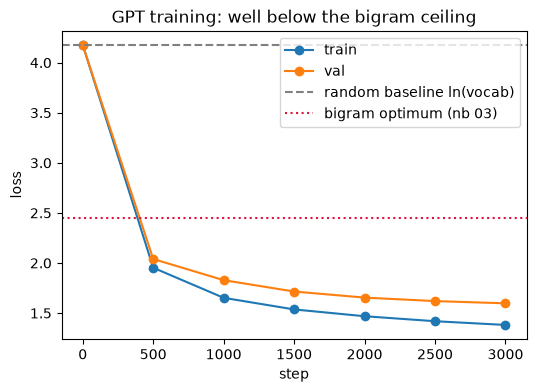

In [6]:
import matplotlib.pyplot as plt
steps = [h[0] for h in history]
plt.figure(figsize=(6,4))
plt.plot(steps, [h[1] for h in history], "o-", label="train")
plt.plot(steps, [h[2] for h in history], "o-", label="val")
plt.axhline(math.log(vocab_size), ls="--", c="gray", label="random baseline ln(vocab)")
plt.axhline(2.452, ls=":", c="crimson", label="bigram optimum (nb 03)")
plt.xlabel("step"); plt.ylabel("loss"); plt.legend(); plt.title("GPT training: well below the bigram ceiling"); plt.show()

<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>import matplotlib.pyplot as plt</code>: the plotting toolbox.</li>
<li><code>steps = [h[0] for h in history]</code>: pull the step numbers out of the recorded triples; <code>h[1]</code> / <code>h[2]</code> pull train / val losses.</li>
<li><code>plt.plot(steps, [h[1] for h in history], "o-", label="train")</code>: the train-loss curve, dots joined by lines.</li>
<li><code>plt.axhline(math.log(vocab_size), ls="--", ...)</code>: a horizontal reference line at ln(65) = 4.17 (random guessing). <code>ls</code> is line style.</li>
<li><code>plt.axhline(2.452, ls=":", ...)</code>: the bigram optimum from notebook 03. Watching the GPT curve dive <i>under</i> that line is the whole point of the picture.</li>
</ul>
</details>

## What the numbers mean, and then hearing it speak

A handy way to *feel* a loss value is to compute `e^loss`, a quantity called the **perplexity**. Roughly, it answers "how many next-characters is the model still torn between?"

- random guessing: loss 4.17, so `e^4.17` is about **65 choices** (all of them, since it knows nothing),
- the bigram ceiling: loss 2.45, so about **12 choices**,
- our GPT: validation loss 1.59, so about **5 choices**.

So training took the model from "could be any of 65 characters" down to "one of about five." That is what breaking through the bigram ceiling looks like: attention let the model use 128 characters of context instead of just one.

Now we sample from it. Compare the result with the bigram's output in notebook 03 and the untrained gibberish in notebook 08. It is the same machinery; it has simply learned.

In [7]:
context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(model.generate(context, max_new_tokens=500)[0].tolist()))



MENENIUS:
Why, for think's bold;'s never I man is
Rends, and in the world delirriages;
But thou hast this thou pray thanks fathin a warms;
And will spil even, by those sompill'd
Off, to-my yourable, no; redult neceiviot sain,
Sir sizen be one peoplexion, more
Highness; wha you'll we sleep the despect off.

MENENIUSS:
So not:
I have like a son of the kingst wind
Of infine, a may at precut of our pooF tears.

POLIXENES:
Thus hear shepherd very as or heart, gone,
Shall as Paul numour all savelia,



<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>torch.zeros((1, 1), dtype=torch.long, device=device)</code>: the prompt: one sequence containing one token, id 0 (newline). A neutral start.</li>
<li><code>model.generate(context, max_new_tokens=500)</code>: 500 dice-rolls of the trained model, each fed back in.</li>
<li><code>[0].tolist()</code>: take the first (only) sequence and convert ids to a plain list for <code>decode</code>.</li>
</ul>
</details>

### Look inside: what the trained heads learned

Notebooks 05 and 06 drew this exact picture for *untrained*, random heads, and every head looked alike. Now the model has trained. Recompute block 0's four attention maps on a real line of text and they have clearly specialised: one head stays on the diagonal (attend to the current character), others lean to earlier characters or lock onto the line's opening. Each head has learned a different way to gather context -- and this structure is what turns the gibberish into Shakespeare.

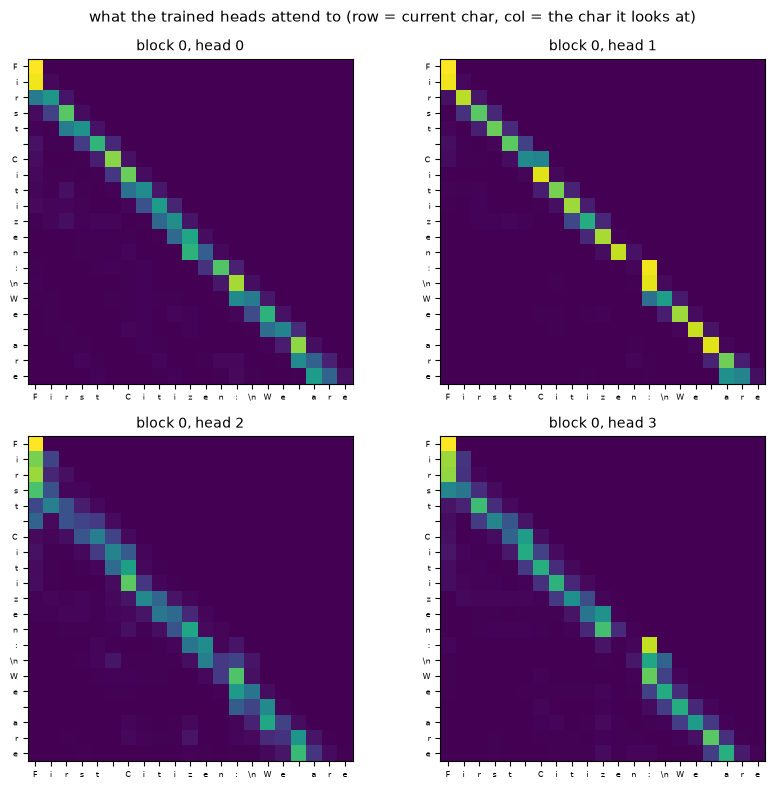

In [8]:
# Recompute block 0's attention on a real snippet, one map per head. Notebooks
# 05-06 drew this for random weights; here the weights are trained.
model.eval()
snippet = "First Citizen:\nWe are"
ids = torch.tensor([[stoi[c] for c in snippet]], device=device)
Tn = len(snippet); labs = [c.replace("\n", "\\n") for c in snippet]

fig, axes = plt.subplots(2, 2, figsize=(8.5, 8))
for H, ax in enumerate(axes.flat):
    with torch.no_grad():
        x = model.token_embedding(ids) + model.position_embedding(torch.arange(Tn, device=device))
        blk = model.blocks[0]; xn = blk.ln1(x); h = blk.sa.heads[H]
        k, q = h.key(xn), h.query(xn)
        w = (q @ k.transpose(-2, -1)) * k.shape[-1] ** -0.5
        w = w.masked_fill(h.tril[:Tn, :Tn] == 0, float("-inf"))
        A = torch.softmax(w, dim=-1)[0].cpu().numpy()
    ax.imshow(A, cmap="viridis")
    ax.set_xticks(range(Tn)); ax.set_xticklabels(labs, fontsize=6)
    ax.set_yticks(range(Tn)); ax.set_yticklabels(labs, fontsize=6)
    ax.set_title(f"block 0, head {H}", fontsize=10)
fig.suptitle("what the trained heads attend to (row = current char, col = the char it looks at)", fontsize=11)
plt.tight_layout(); plt.show()

<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>model.eval()</code>: turn off dropout so the attention we read is the clean, deterministic version.</li>
<li>For each of block 0's four heads it recomputes the attention by hand: embed the snippet, LayerNorm it, then <code>softmax(q @ k.T / sqrt(head_size))</code> with the future masked -- exactly the formula from notebook 05.</li>
<li>Each heatmap row is a character; the bright cells along that row are the earlier characters it attends to.</li>
<li>Unlike the near-identical random heads in notebook 06, these have specialised: compare the four -- diagonal (the current character), one-step-back, and longer-range -- each head learned a different job.</li>
<li>Stack four such heads across four blocks and train for 3000 steps, and this learned structure is what turns gibberish into Shakespeare.</li>
</ul>
</details>

## Save the trained model

We store the weights, the config, and the tokenizer, so that notebook 10 can load this exact model and explore sampling without retraining it.

In [9]:
import os
os.makedirs("checkpoints", exist_ok=True)
torch.save({"model": model.state_dict(), "config": cfg, "stoi": stoi, "itos": itos},
           "checkpoints/gpt_shakespeare.pt")
print("saved -> checkpoints/gpt_shakespeare.pt")

saved -> checkpoints/gpt_shakespeare.pt


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>os.makedirs("checkpoints", exist_ok=True)</code>: create the folder; the flag means "fine if it already exists."</li>
<li><code>model.state_dict()</code>: every learned weight, as a dictionary of tensors. This <i>is</i> the trained model.</li>
<li><code>torch.save({"model": ..., "config": cfg, "stoi": stoi, "itos": itos}, "checkpoints/gpt_shakespeare.pt")</code>: bundle weights + config + tokenizer into one file, so notebook 10 can reload exactly this model without retraining.</li>
</ul>
</details>

## Chapter 29: the learning-rate schedule

The run above held the learning rate at a flat `1e-3`. Real runs vary it on a **schedule** with two phases. **Warmup** ramps the rate linearly from ~0 to its peak over the first few hundred steps, so the first steps do not fling the still-random weights around. **Decay** then eases it down along a cosine curve to a small floor, so late training settles rather than bounces.

In [10]:
import math

def lr_at(step, warmup=100, total=1000,
          hi=3e-4, lo=3e-5):
    if step < warmup:
        return hi * step / warmup
    p = (step - warmup) / (total - warmup)
    return lo + 0.5 * (hi - lo) * (1 + math.cos(math.pi * p))


for s in [0, 50, 100, 550, 1000]:
    print(f"step {s:>4}: lr = {lr_at(s):.6g}")


step    0: lr = 0
step   50: lr = 0.00015
step  100: lr = 0.0003
step  550: lr = 0.000165
step 1000: lr = 3e-05


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>hi=3e-4, lo=3e-5</code>: the peak and the floor. <code>hi</code> is whatever rate you would have picked without a schedule; <code>lo</code> is a tenth of it, the usual choice, so late training still moves rather than freezing.</li>
<li><code>if step &lt; warmup:</code>: the ramp &mdash; a straight line from 0 up to <code>hi</code>.</li>
<li><code>p = (step - warmup) / (total - warmup)</code>: progress through the decay phase: 0.0 at the end of warmup, 1.0 at the end of training.</li>
<li><code>math.cos(math.pi * p)</code>: runs from cos(0) = +1 down to cos(&pi;) = &minus;1, so <code>(1 + cos)</code> runs 2 &rarr; 0, and the <code>0.5</code> in front turns that into a factor from 1 down to 0.</li>
<li><code>for s in [0, 50, 100, 550, 1000]:</code>: read the rate off at five points: the start, mid-ramp, the peak, mid-decay, and the floor.</li>
</ul>
</details>

The cosine's flat top and flat bottom are the point: the rate lingers near its peak while the model is learning fastest, then flattens out near the floor instead of crashing into it.

At the cosine's midpoint the rate is exactly halfway between floor and peak, 3e-5 + (3e-4 &minus; 3e-5)/2 = 1.65e-4, which is a useful sanity check when you implement one.

To use it, set the rate on the optimizer at the top of each step:

```python
for g in optimizer.param_groups:
    g["lr"] = lr_at(step, warmup=200, total=max_iters,
                    hi=3e-3, lo=3e-4)
```

That is exercise 6 of Chapter 29: run it against the flat `lr=1e-3` baseline and compare the validation curves at steps 500, 1500 and 3000.

## Chapter 29: gradient clipping

Occasionally one batch produces enormous gradients, and a single step on them can undo hours of training. **Gradient clipping** treats every gradient in the model as one long vector, measures its length (its *norm*), and if that is over a threshold, scales the whole vector down to exactly the threshold. The direction of the step is untouched; only its size is capped.

In PyTorch it is one line, between `backward()` and `step()`. Here it is in place, in one training step:

In [ ]:
x, y = get_batch("train")
_, loss = model(x, y)
optimizer.zero_grad(set_to_none=True)
loss.backward()
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
optimizer.step()


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>x, y = get_batch(&quot;train&quot;)</code>: one step of the training loop above: a batch, then the forward pass that returns the loss, then <code>zero_grad</code> to clear the old gradients.</li>
<li><code>loss.backward()</code>: compute fresh gradients. The fresh forward pass above is not optional: <code>backward()</code> frees the record of the computation once it has walked it, so calling it again on the loop's last loss fails with &quot;Trying to backward through the graph a second time&quot;.</li>
<li><code>torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)</code>: measure the combined norm of every gradient in the model and, if it is above 1.0, scale them all down by the same factor. The trailing underscore means it works in place, so the gradients need no assigning back; it also returns the norm it measured, which is worth printing when you hunt exploding gradients.</li>
<li><code>optimizer.step()</code>: apply the clipped gradients: the model takes one more step. In a real training loop the clipping line sits in exactly this spot, on every step.</li>
</ul>
</details>

## Recap

You trained a GPT that you built from scratch. The loss fell from about 4.2 to well below the bigram ceiling, and the samples look like Shakespeare because predicting the next character *well* forced the model to learn spelling, character names, and the shape of dialogue. That is the course's central idea, made real.

Next, notebook 10 covers how to control the way it generates (temperature, top-k, and top-p), and offers a tour of what separates this from a frontier model.